# Hardest Route to the Title — Elo vs FIFA

We score every Round-of-32 team's **road to the trophy** through the real
[official 2026 knockout bracket](https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_knockout_stage)
(hard-coded in `knockout_paths_elo.bracket`). Who you face each round is the
winner of the sibling sub-bracket, so expected opponents are weighted by how
likely each rival is to actually be there.

We run the analysis **separately under two independent rating systems**:

1. **Eloratings** — World Football Elo (`data/elo_ratings.csv`, `rating`), win
   probability on the classic **/400** scale.
2. **FIFA** — the FIFA/Coca-Cola ranking (`data/fifa_rankings.csv`). Two angles:
   - **points** (`total_points`) with FIFA's own **/600** win-probability scale;
   - **ranking** (`rank`) — the average rank-number of opponents faced.

Higher expected opponent strength = **harder route**.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_rows", 50)

# Make the project package importable when running from notebooks/.
for base in (Path.cwd(), *Path.cwd().parents):
    if (base / "knockout_paths_elo").is_dir():
        sys.path.insert(0, str(base))
        break

from knockout_paths_elo.bracket import (
    build_official_bracket,
    advancement_distribution,
    champion_probabilities,
    path_difficulty,
    win_probability,
    fifa_win_probability,
    R32_MATCHUPS,
)
print(sys.executable)

E:\Code\knockout-paths-elo\.venv\Scripts\python.exe


## 1. Load both rating systems

Both CSVs key teams by the same names used in the bracket, so lookups line up.

In [2]:
def data_dir() -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "data" / "elo_ratings.csv").exists():
            return base / "data"
    raise FileNotFoundError("data/ not found")

DATA = data_dir()
elo_df = pd.read_csv(DATA / "elo_ratings.csv")
fifa_df = pd.read_csv(DATA / "fifa_rankings.csv")

elo_rating = dict(zip(elo_df["team"], elo_df["rating"]))
fifa_points = dict(zip(fifa_df["team"], fifa_df["total_points"]))
fifa_rank = dict(zip(fifa_df["team"], fifa_df["rank"]))

print(f"Elo: {len(elo_rating)} teams | FIFA: {len(fifa_points)} teams")

Elo: 48 teams | FIFA: 48 teams


## 2. The official bracket

`build_official_bracket()` turns the hard-coded R32 matchups into a 32-leaf
binary tree; advancement above the bottom layer is decided by the chosen rating
system.

In [3]:
root = build_official_bracket()
teams = [leaf.team for leaf in root.leaves()]
assert len(teams) == 32 and set(teams) <= set(elo_rating) and set(teams) <= set(fifa_points)

print(f"Tree: {root.size} leaves, root round = {root.round_name}\n")
print("Round of 32 matchups (bracket order):")
for a, b in R32_MATCHUPS:
    print(f"  {a:<22} vs  {b}")

Tree: 32 leaves, root round = R32

Round of 32 matchups (bracket order):
  Germany                vs  Paraguay
  France                 vs  Sweden
  South Africa           vs  Canada
  Netherlands            vs  Morocco
  Portugal               vs  Croatia
  Spain                  vs  Austria
  USA                    vs  Bosnia & Herzegovina
  Belgium                vs  Senegal
  Brazil                 vs  Japan
  Ivory Coast            vs  Norway
  Mexico                 vs  Ecuador
  England                vs  DR Congo
  Argentina              vs  Cape Verde
  Australia              vs  Egypt
  Switzerland            vs  Algeria
  Colombia               vs  Ghana


## 3. Scoring helpers

`path_difficulty` (from the module) gives, per team, the expected opponent
**rating** each round and the product of round win-probabilities (= probability
of running the table = winning the title). `avg_opp_rating` is the per-round mean
— our headline "hardness" number. For the FIFA-ranking view we also average the
opponents' **rank-number** using the same advancement distributions.

In [4]:
def difficulty_table(root, teams, ratings, prob, rating_label):
    rows = []
    for t in teams:
        pdif = path_difficulty(root, t, ratings, prob)
        rows.append({
            "team": t,
            rating_label: ratings[t],
            "avg_opp_" + rating_label: pdif.strength_of_schedule / len(pdif.steps),
            "p_champion": pdif.run_the_table_prob,
        })
    df = pd.DataFrame(rows)
    df["hardness_rank"] = df["avg_opp_" + rating_label].rank(ascending=False).astype(int)
    return df.sort_values("avg_opp_" + rating_label, ascending=False).reset_index(drop=True)


def opponents_per_round(root, team, ratings, prob):
    # -> [(round_name, {opponent: P(faces them)})] from R32 to Final
    path = []
    def find(n):
        path.append(n)
        if n.is_leaf:
            if n.team == team:
                return True
        elif find(n.left) or find(n.right):
            return True
        path.pop()
        return False
    find(root)
    out = []
    for parent, child in zip(path, path[1:]):
        sib = parent.right if parent.left is child else parent.left
        out.append((parent.round_name, advancement_distribution(sib, ratings, prob)))
    return list(reversed(out))


def show_road(root, team, ratings, prob, unit):
    pdif = path_difficulty(root, team, ratings, prob)
    print(f"Round-by-round road for {team}:")
    for s in pdif.steps:
        print(f"  {s.round_name:<6} exp opp {unit} {s.exp_opponent_rating:7.0f}"
              f"   win prob {s.exp_win_prob:5.1%}")


def plot_hardest(df, value_col, title, xlabel, color, ascending_hard=False, n=32):
    top = df.sort_values(value_col, ascending=ascending_hard).head(n)[::-1]
    fig, ax = plt.subplots(figsize=(9, max(6, 0.32 * len(top))))
    ax.barh(top["team"], top[value_col], color=color)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

## 4. Hardest route — Eloratings  (/400)

In [5]:
elo_routes = difficulty_table(root, teams, elo_rating, win_probability, "elo")
elo_routes

,team,elo,avg_opp_elo,p_champion,hardness_rank
0,DR Congo,1666,2004.334109,0.000040,1
1,Algeria,1780,2002.963730,0.000620,2
2,Austria,1841,2002.528416,0.001688,3
3,Ghana,1584,2001.323955,0.000007,4
4,Ivory Coast,1743,2001.076160,0.000271,5
5,Croatia,1896,2000.331647,0.005337,6
6,Japan,1910,1998.866907,0.007173,7
7,Sweden,1742,1997.752131,0.000268,8
8,Paraguay,1815,1997.348491,0.001398,9
9,Ecuador,1902,1997.292285,0.006636,10


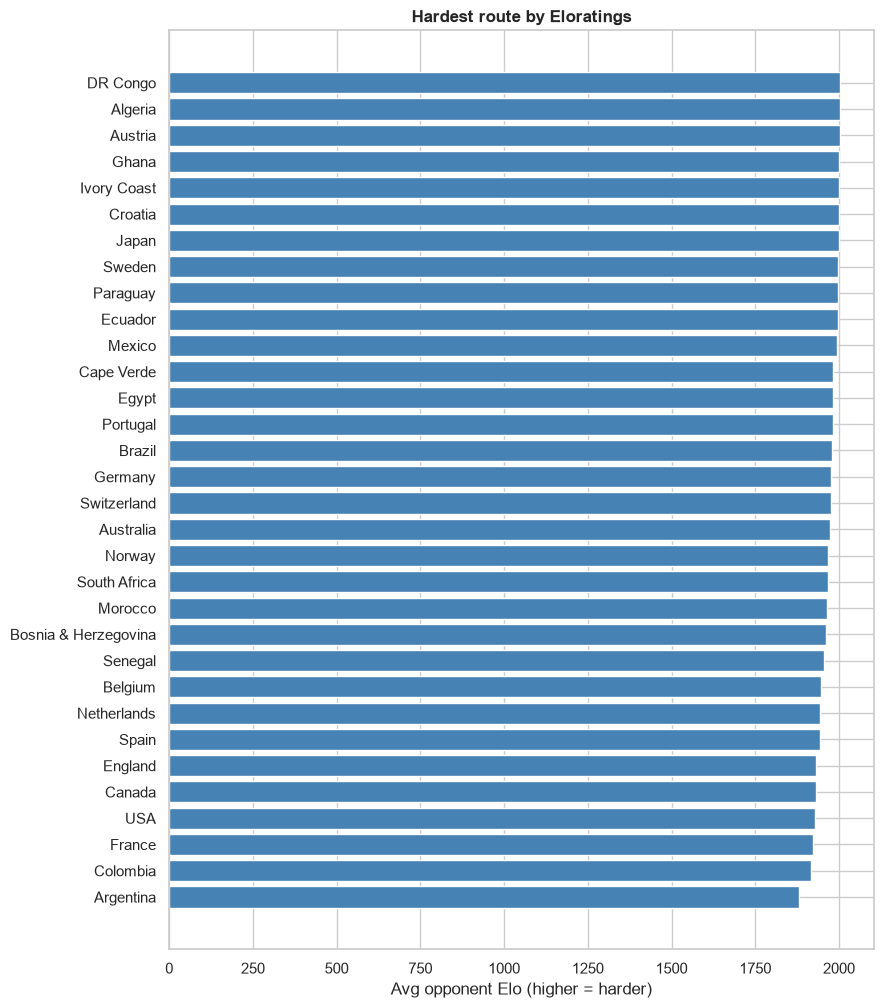

Round-by-round road for DR Congo:
  Final  exp opp Elo    2028   win prob 11.1%
  SF     exp opp Elo    1907   win prob 20.0%
  QF     exp opp Elo    1946   win prob 17.3%
  R16    exp opp Elo    2072   win prob 10.2%
  R32    exp opp Elo    2068   win prob 10.3%


In [6]:
plot_hardest(elo_routes, "avg_opp_elo",
             "Hardest route by Eloratings", "Avg opponent Elo (higher = harder)",
             "steelblue")
show_road(root, elo_routes.iloc[0]["team"], elo_rating, win_probability, "Elo")

## 5. Hardest route — FIFA points  (/600)

In [7]:
fifa_routes = difficulty_table(root, teams, fifa_points, fifa_win_probability, "fifapts")
fifa_routes

,team,fifapts,avg_opp_fifapts,p_champion,hardness_rank
0,Austria,1597,1765.207639,0.004810,1
1,Croatia,1715,1755.736902,0.020605,2
2,Sweden,1510,1749.716505,0.001947,3
3,Paraguay,1505,1748.748753,0.001965,4
4,Portugal,1768,1745.136902,0.037654,5
5,Bosnia & Herzegovina,1387,1740.525023,0.000401,6
6,DR Congo,1474,1734.247601,0.001487,7
7,Senegal,1684,1731.389092,0.018693,8
8,Ecuador,1599,1727.098438,0.008152,9
9,South Africa,1428,1722.037533,0.000931,10


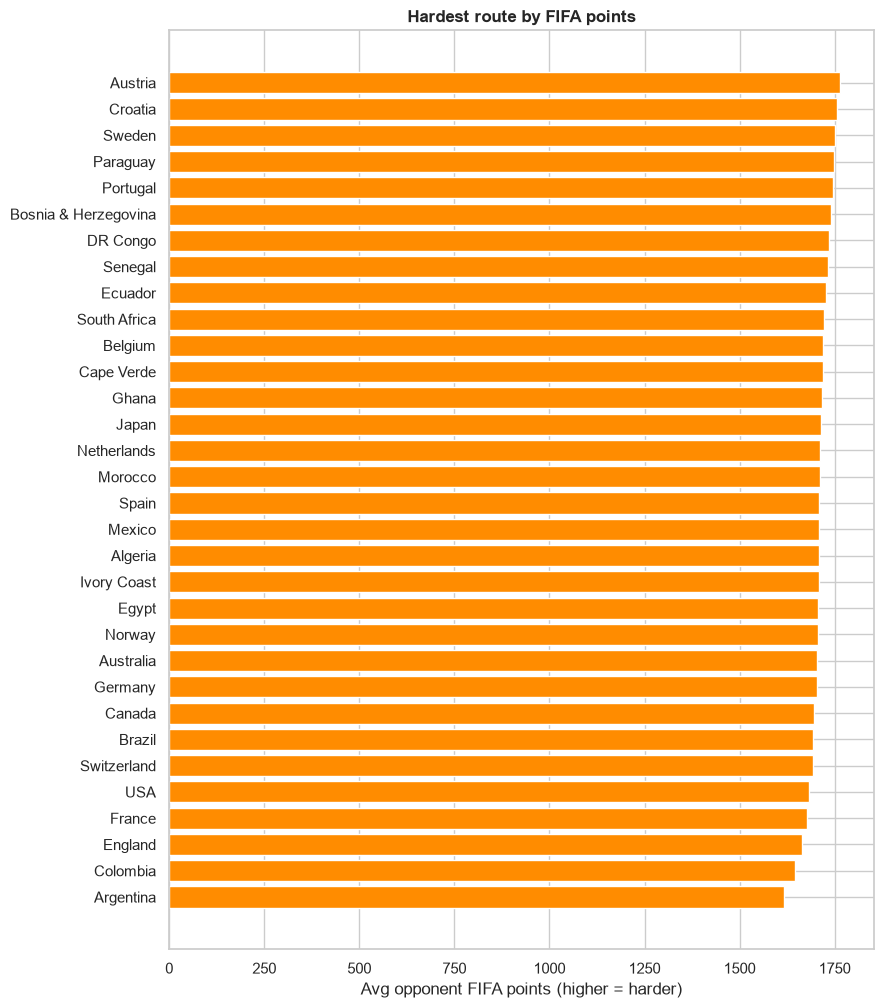

Round-by-round road for Austria:
  Final  exp opp pts    1875   win prob 25.6%
  SF     exp opp pts    1744   win prob 36.3%
  QF     exp opp pts    1683   win prob 41.8%
  R16    exp opp pts    1763   win prob 35.1%
  R32    exp opp pts    1761   win prob 35.3%


In [8]:
plot_hardest(fifa_routes, "avg_opp_fifapts",
             "Hardest route by FIFA points", "Avg opponent FIFA points (higher = harder)",
             "darkorange")
show_road(root, fifa_routes.iloc[0]["team"], fifa_points, fifa_win_probability, "pts")

## 6. Hardest route — FIFA ranking

Average **rank-number** of expected opponents (lower number = stronger field =
harder). Who advances is decided by the FIFA points model.

In [9]:
rank_rows = []
for t in teams:
    steps = opponents_per_round(root, t, fifa_points, fifa_win_probability)
    exp_ranks = [sum(p * fifa_rank[o] for o, p in dist.items()) for _, dist in steps]
    rank_rows.append({
        "team": t,
        "fifa_rank": fifa_rank[t],
        "avg_opp_fifa_rank": float(np.mean(exp_ranks)),
    })
rank_routes = pd.DataFrame(rank_rows)
rank_routes["hardness_rank"] = rank_routes["avg_opp_fifa_rank"].rank(ascending=True).astype(int)
rank_routes = rank_routes.sort_values("avg_opp_fifa_rank").reset_index(drop=True)
rank_routes

,team,fifa_rank,avg_opp_fifa_rank,hardness_rank
0,Austria,24,9.222701,1
1,Croatia,11,9.809909,2
2,Portugal,5,11.009909,3
3,Bosnia & Herzegovina,64,11.052183,4
4,Paraguay,41,11.094548,5
5,Sweden,38,11.502902,6
6,DR Congo,46,11.919165,7
7,Senegal,15,12.884090,8
8,Ecuador,23,12.887341,9
9,South Africa,60,13.419951,10


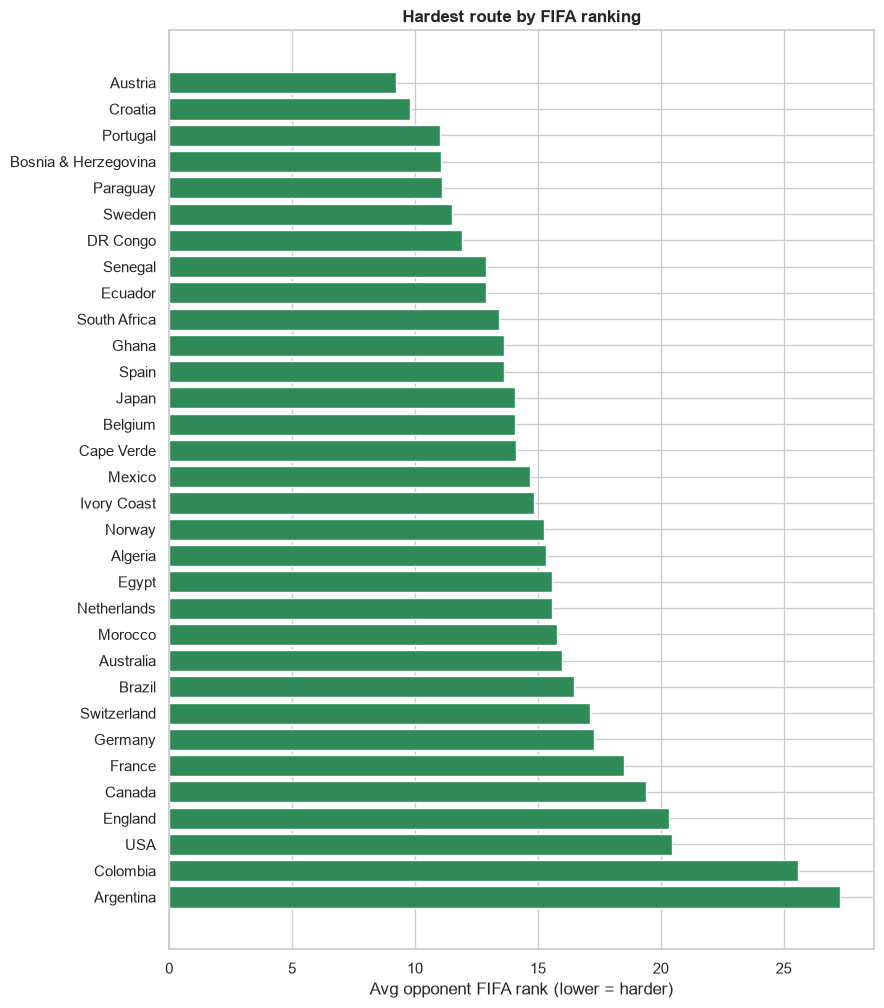

In [10]:
plot_hardest(rank_routes, "avg_opp_fifa_rank",
             "Hardest route by FIFA ranking", "Avg opponent FIFA rank (lower = harder)",
             "seagreen", ascending_hard=True)

## 7. Side-by-side

Each system's hardness rank (1 = toughest road). Elo and FIFA-points reward
beating high-rated teams; FIFA-ranking rewards facing low rank-numbers — they
mostly agree but can disagree where the two systems disagree on a team's strength.

In [11]:
compare = (
    elo_routes[["team", "hardness_rank"]].rename(columns={"hardness_rank": "elo_rank"})
    .merge(fifa_routes[["team", "hardness_rank"]].rename(columns={"hardness_rank": "fifapts_rank"}), on="team")
    .merge(rank_routes[["team", "hardness_rank"]].rename(columns={"hardness_rank": "fifarank_rank"}), on="team")
)
compare["avg_rank"] = compare[["elo_rank", "fifapts_rank", "fifarank_rank"]].mean(axis=1)
compare.sort_values("avg_rank").reset_index(drop=True)

,team,elo_rank,fifapts_rank,fifarank_rank,avg_rank
0,Austria,3,1,1,1.666667
1,Croatia,6,2,2,3.333333
2,DR Congo,1,7,7,5.000000
3,Sweden,8,3,6,5.666667
4,Paraguay,9,4,5,6.000000
5,Portugal,14,5,3,7.333333
6,Ghana,4,13,11,9.333333
7,Ecuador,10,9,9,9.333333
8,Bosnia & Herzegovina,22,6,4,10.666667
9,Japan,7,14,13,11.333333


## 8. Bonus — most probable winner under each system

The product of expected round win-probs along a team's path is exactly its title
probability, so each system also yields a favourite.

In [12]:
champ_elo = champion_probabilities(root, elo_rating, win_probability)
champ_fifa = champion_probabilities(root, fifa_points, fifa_win_probability)

winners = (
    pd.DataFrame({"team": teams})
    .assign(p_elo=lambda d: d["team"].map(champ_elo),
            p_fifa=lambda d: d["team"].map(champ_fifa))
    .sort_values("p_elo", ascending=False)
    .reset_index(drop=True)
)
winners.style.format({"p_elo": "{:.1%}", "p_fifa": "{:.1%}"})

,team,p_elo,p_fifa
0,Argentina,26.9%,17.8%
1,Spain,21.5%,11.3%
2,France,19.8%,12.9%
3,England,7.0%,10.6%
4,Colombia,5.4%,4.0%
5,Brazil,4.1%,5.5%
6,Netherlands,3.7%,4.2%
7,Portugal,2.8%,3.8%
8,Norway,1.2%,0.6%
9,Germany,1.1%,3.8%


## 9. Easiest routes (inverse)

The mirror image of the hardest-route charts above: same metric for each system,
but now the team with the **softest** expected road sits on top.

In [13]:
def plot_easiest(df, value_col, title, xlabel, color, ascending_hard=False, n=32):
    # Easiest = the opposite extreme of the hardness metric used in plot_hardest.
    top = df.sort_values(value_col, ascending=not ascending_hard).head(n)[::-1]
    fig, ax = plt.subplots(figsize=(9, max(6, 0.32 * len(top))))
    ax.barh(top["team"], top[value_col], color=color)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

### Easiest route — Eloratings

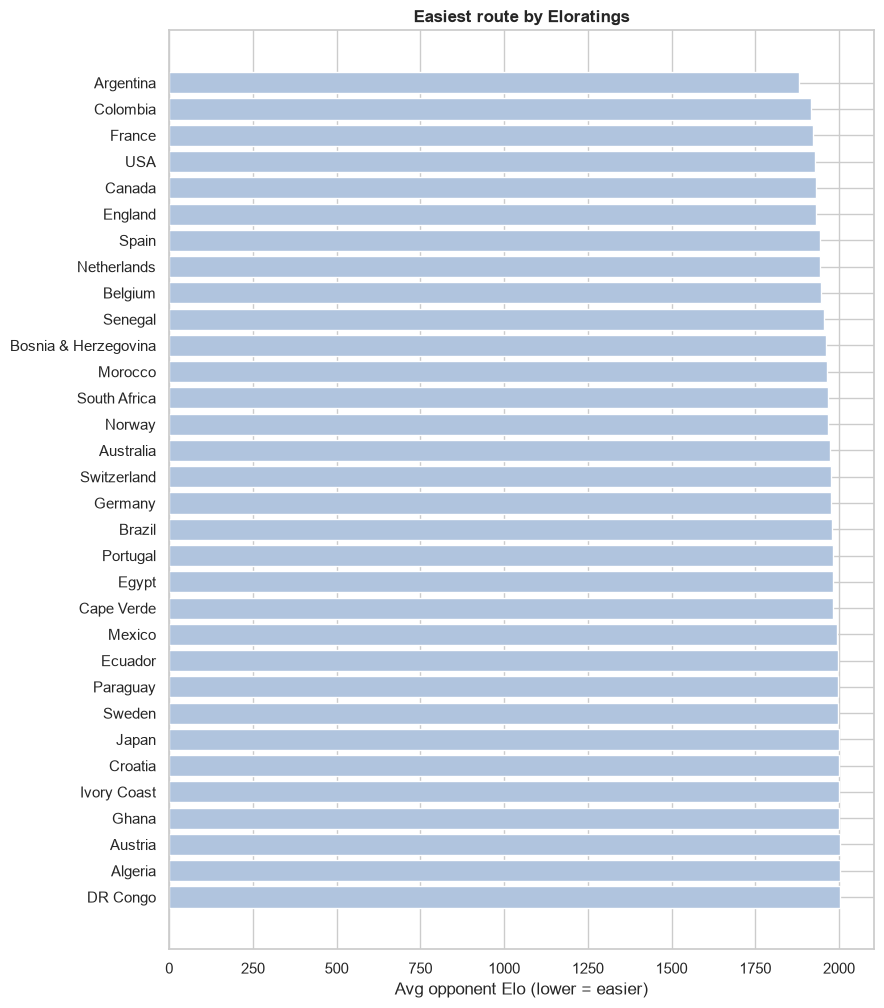

In [14]:
plot_easiest(elo_routes, "avg_opp_elo",
             "Easiest route by Eloratings", "Avg opponent Elo (lower = easier)",
             "lightsteelblue")

### Easiest route — FIFA points

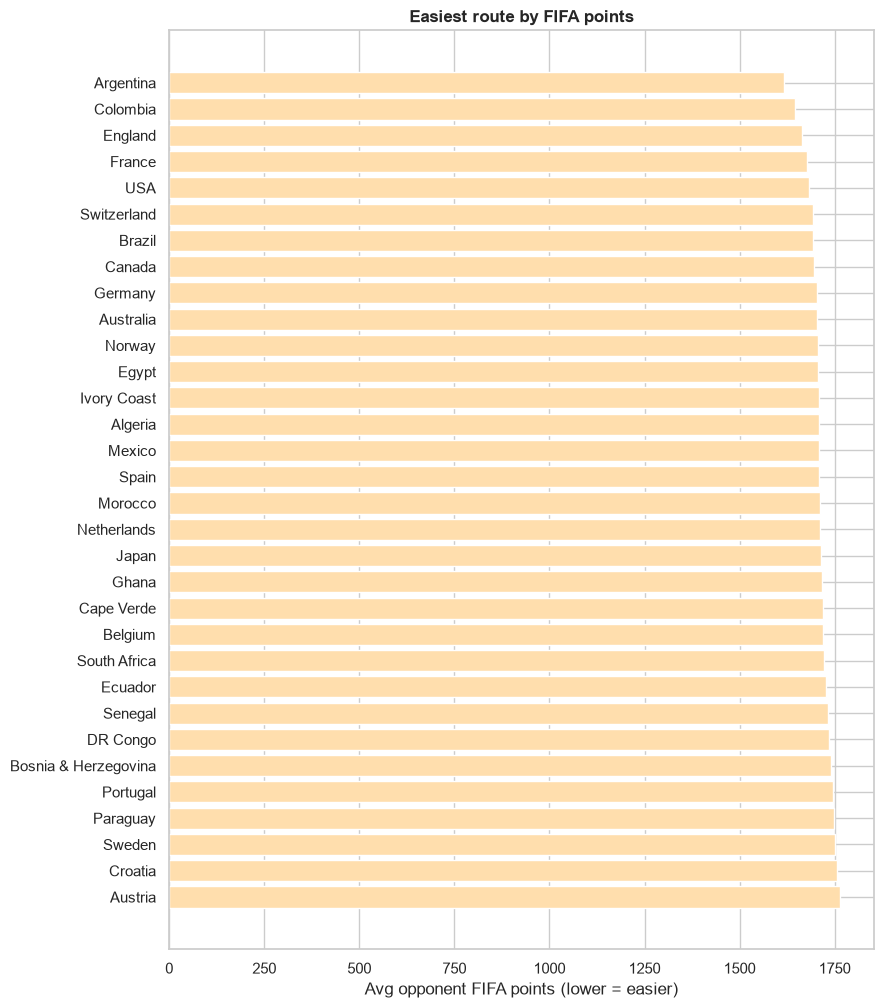

In [15]:
plot_easiest(fifa_routes, "avg_opp_fifapts",
             "Easiest route by FIFA points", "Avg opponent FIFA points (lower = easier)",
             "navajowhite")

### Easiest route — FIFA ranking

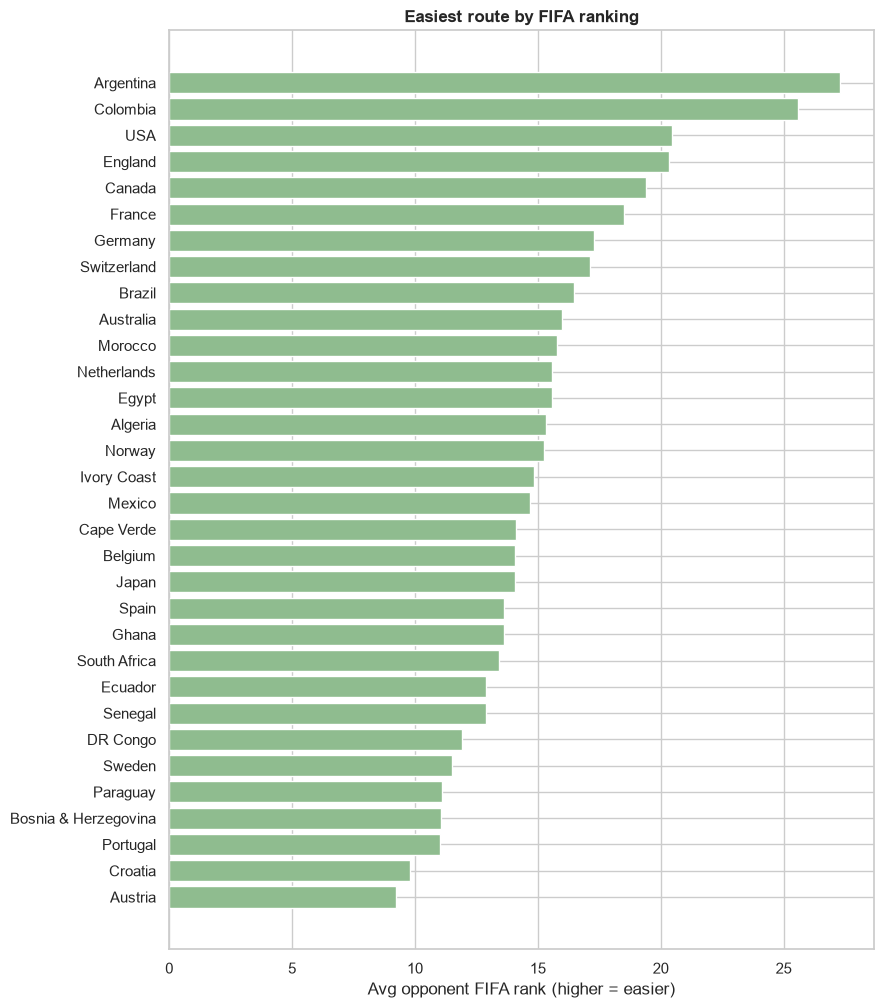

In [16]:
plot_easiest(rank_routes, "avg_opp_fifa_rank",
             "Easiest route by FIFA ranking", "Avg opponent FIFA rank (higher = easier)",
             "darkseagreen", ascending_hard=True)

## 10. Routes by Elo momentum (1-year change)

A **form** bracket: instead of absolute strength we use each team's Elo change
over the last year (`rating_change_1y`) as the rating. Advancement is decided by
who is trending up more, and a route is hard when the opponents you expect to
meet are the ones rising fastest. Values are deltas (can be negative) on the same
Elo scale, so we keep the /400 win-probability model.

In [17]:
form_rating = dict(zip(elo_df["team"], elo_df["rating_change_1y"]))
form_routes = difficulty_table(root, teams, form_rating, win_probability, "elo1y")
form_routes

,team,elo1y,avg_opp_elo1y,p_champion,hardness_rank
0,Norway,52,74.489833,0.021499,1
1,Colombia,56,74.271201,0.023635,2
2,Ecuador,-3,74.246850,0.009134,3
3,Argentina,12,72.735506,0.012043,4
4,Brazil,8,71.033560,0.011589,5
5,Switzerland,70,70.504138,0.030811,6
6,England,44,70.334231,0.021050,7
7,Australia,25,70.272959,0.015634,8
8,Algeria,76,69.304138,0.034120,9
9,Ghana,107,64.071201,0.055232,10


### Hardest route — Elo 1-year change

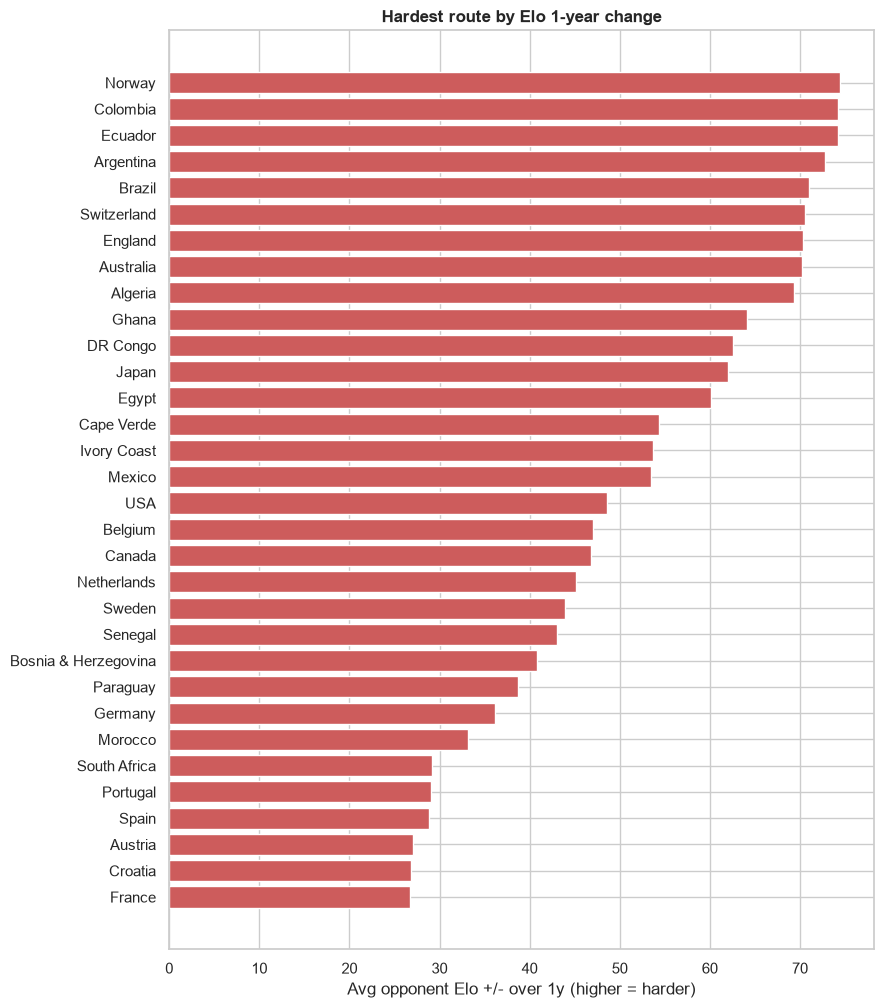

Round-by-round road for Norway:
  Final  exp opp dElo1y     156   win prob 35.5%
  SF     exp opp dElo1y      33   win prob 52.7%
  QF     exp opp dElo1y      69   win prob 47.6%
  R16    exp opp dElo1y      76   win prob 46.6%
  R32    exp opp dElo1y      38   win prob 51.9%


In [18]:
plot_hardest(form_routes, "avg_opp_elo1y",
             "Hardest route by Elo 1-year change",
             "Avg opponent Elo +/- over 1y (higher = harder)", "indianred")
show_road(root, form_routes.iloc[0]["team"], form_rating, win_probability, "dElo1y")

### Easiest route — Elo 1-year change

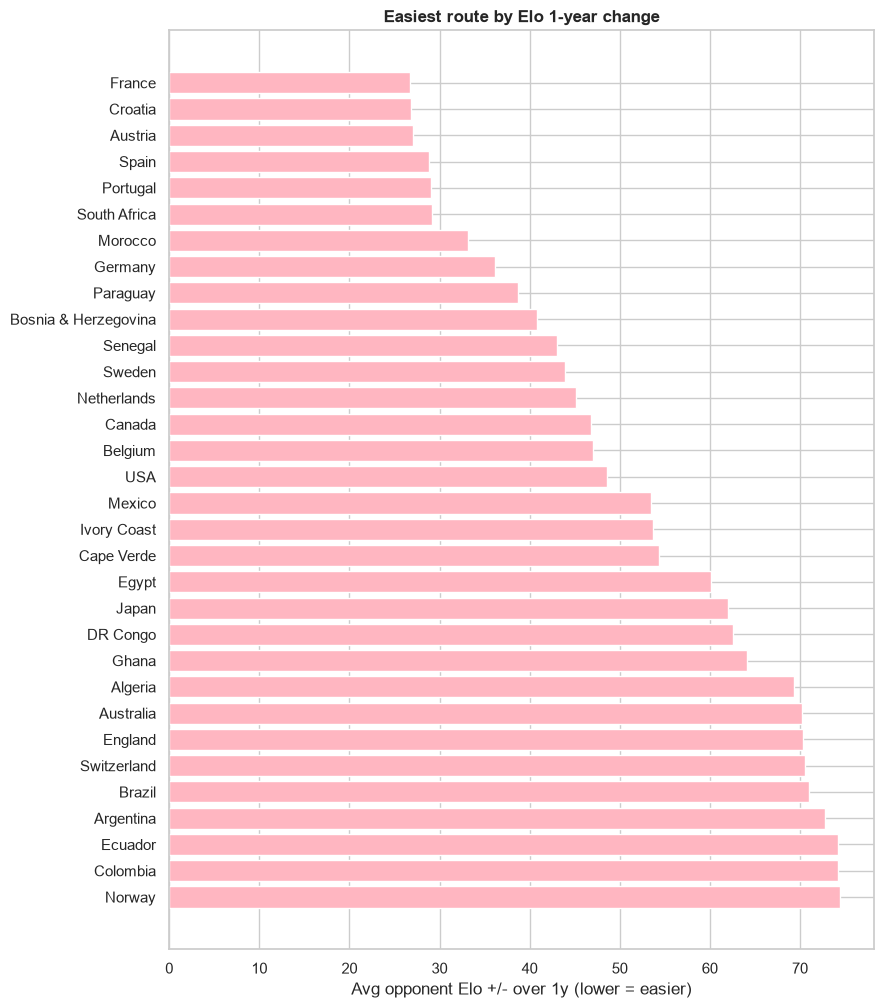

In [19]:
plot_easiest(form_routes, "avg_opp_elo1y",
             "Easiest route by Elo 1-year change",
             "Avg opponent Elo +/- over 1y (lower = easier)", "lightpink")

## 11. Routes by blended rating (Elo + recent form)

Current strength nudged by momentum: **`blended = Elo + w * (1-year Elo change)`**.
With `w = 0.5` a fast-rising side gets a boost and a fading one a penalty, while
the rating stays on the full Elo scale so the /400 win-probability model stays
decisive (unlike the pure-momentum bracket). Raise `w` to trust recent form more.

In [20]:
MOMENTUM_WEIGHT = 0.5
blend_rating = {t: elo_rating[t] + MOMENTUM_WEIGHT * form_rating[t] for t in teams}
blend_routes = difficulty_table(root, teams, blend_rating, win_probability, "blend")
blend_routes

,team,blend,avg_opp_blend,p_champion,hardness_rank
0,Algeria,1818.0,2021.859541,0.000927,1
1,DR Congo,1707.5,2021.858009,0.000071,2
2,Ghana,1637.5,2020.819619,0.000016,3
3,Ecuador,1900.5,2018.591255,0.004530,4
4,Ivory Coast,1821.0,2017.709086,0.000997,5
5,Japan,1936.5,2015.582614,0.008629,6
6,Austria,1839.0,2010.508668,0.001427,7
7,Croatia,1880.5,2007.968766,0.003646,8
8,Paraguay,1810.0,2007.467424,0.001012,9
9,Sweden,1733.0,2006.735386,0.000172,10


### Hardest route — blended rating

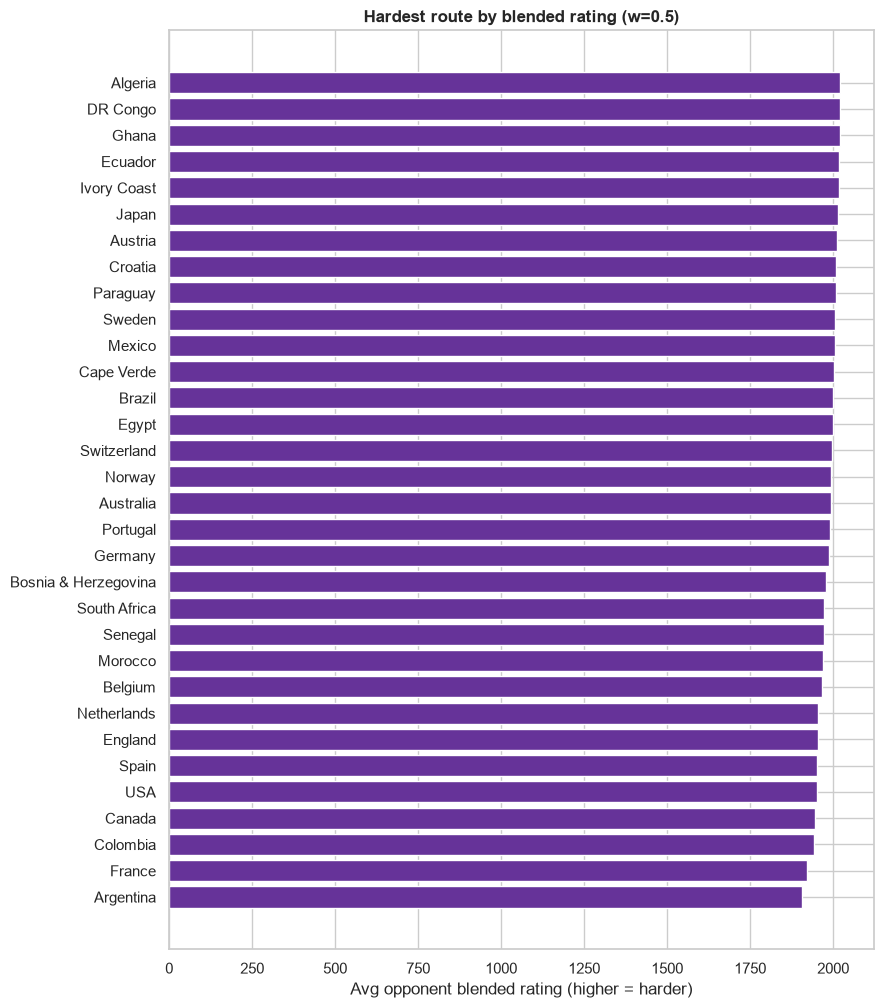

Round-by-round road for Algeria:
  Final  exp opp blend    1949   win prob 32.0%
  SF     exp opp blend    1997   win prob 27.2%
  QF     exp opp blend    2088   win prob 20.0%
  R16    exp opp blend    1991   win prob 27.5%
  R32    exp opp blend    2084   win prob 19.4%


In [21]:
plot_hardest(blend_routes, "avg_opp_blend",
             f"Hardest route by blended rating (w={MOMENTUM_WEIGHT})",
             "Avg opponent blended rating (higher = harder)", "rebeccapurple")
show_road(root, blend_routes.iloc[0]["team"], blend_rating, win_probability, "blend")

### Easiest route — blended rating

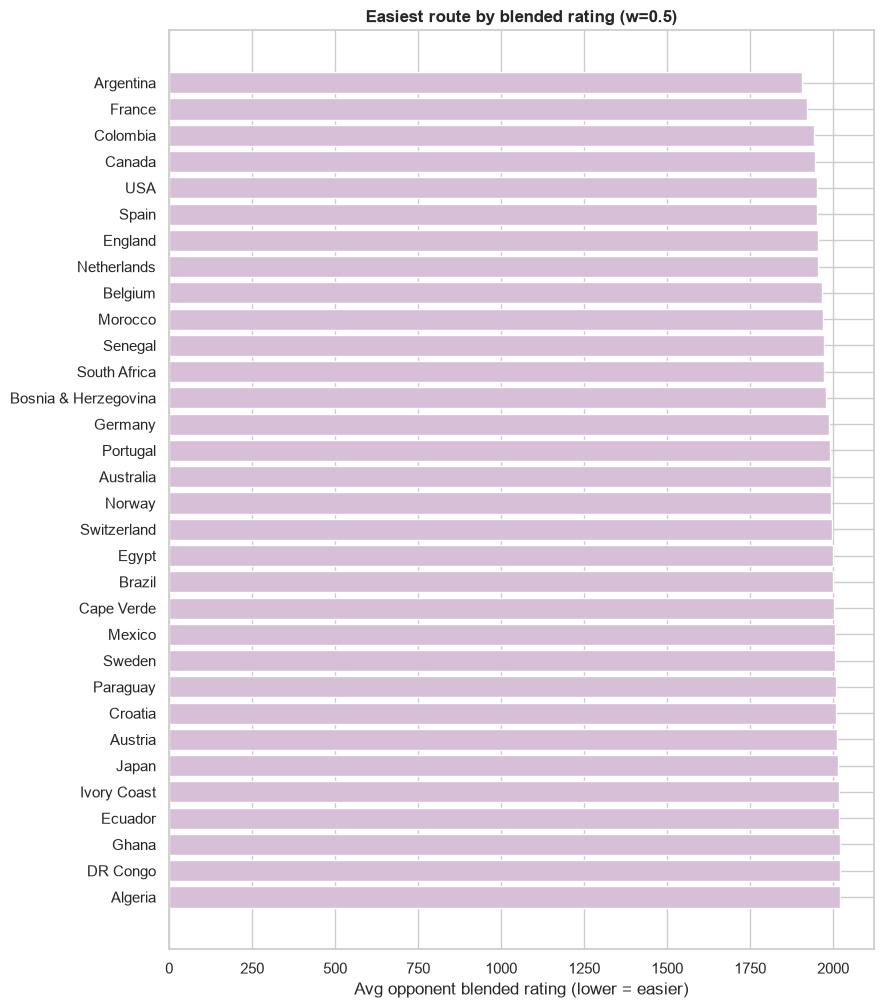

In [22]:
plot_easiest(blend_routes, "avg_opp_blend",
             f"Easiest route by blended rating (w={MOMENTUM_WEIGHT})",
             "Avg opponent blended rating (lower = easier)", "thistle")